In [2]:
# !pip install torchvision

In [3]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [10]:
# images load => transform => dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

In [11]:
root_dir_path = "./img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178), # 178x218 => 178x178
    transforms.Resize(64), # 64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
])

In [12]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [13]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

## Generator Network

In [27]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [28]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512), 
            nn.ReLU(),

            nn.Linear(512, 1024), 
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels), 
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64) 
        return img

        # fake img => 64 x 64 x 3 x batch_size

## Discriminator Network

In [29]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D
            
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1), 
            nn.Sigmoid() # probability of being real/fake 
        )

    def forward(self, img):
        return self.model(img)

In [30]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [31]:
import torch
# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is mps


In [32]:
generator = generator.to(device)
discriminator = discriminator.to(device)

## Training the GAN

In [36]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device) 

In [39]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/5... batch: 1... G-loss:3.322542190551758.... D-loss: 0.3139531910419464
for epoch: 1/5... batch: 51... G-loss:2.3338780403137207.... D-loss: 0.33996284008026123
for epoch: 1/5... batch: 101... G-loss:1.9056925773620605.... D-loss: 0.27508699893951416
for epoch: 1/5... batch: 151... G-loss:2.290879726409912.... D-loss: 0.31506916880607605
for epoch: 1/5... batch: 201... G-loss:3.2655439376831055.... D-loss: 0.38347920775413513
for epoch: 1/5... batch: 251... G-loss:1.425288200378418.... D-loss: 0.4764195680618286
for epoch: 1/5... batch: 301... G-loss:2.7879319190979004.... D-loss: 0.3383023738861084
for epoch: 1/5... batch: 351... G-loss:2.234636068344116.... D-loss: 0.5133187174797058
for epoch: 1/5... batch: 401... G-loss:3.0106489658355713.... D-loss: 0.3158843517303467
for epoch: 1/5... batch: 451... G-loss:2.420163154602051.... D-loss: 0.33349305391311646
for epoch: 1/5... batch: 501... G-loss:2.933938980102539.... D-loss: 0.40808793902397156
for epoch: 1/5... batch:

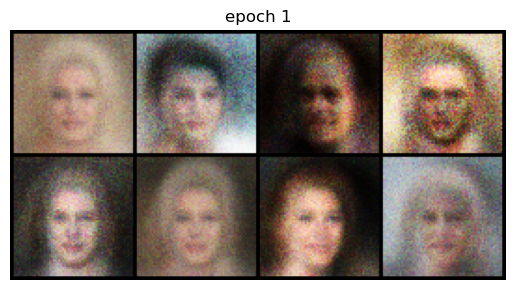

for epoch: 2/5... batch: 1... G-loss:2.224043130874634.... D-loss: 0.3620590269565582
for epoch: 2/5... batch: 51... G-loss:1.9637258052825928.... D-loss: 0.3923010230064392
for epoch: 2/5... batch: 101... G-loss:2.2164976596832275.... D-loss: 0.39461421966552734
for epoch: 2/5... batch: 151... G-loss:2.699800968170166.... D-loss: 0.41392046213150024
for epoch: 2/5... batch: 201... G-loss:1.8283586502075195.... D-loss: 0.3859618902206421
for epoch: 2/5... batch: 251... G-loss:2.3580565452575684.... D-loss: 0.4057340621948242
for epoch: 2/5... batch: 301... G-loss:1.7985527515411377.... D-loss: 0.48905372619628906
for epoch: 2/5... batch: 351... G-loss:1.6815409660339355.... D-loss: 0.4434852600097656
for epoch: 2/5... batch: 401... G-loss:1.9040369987487793.... D-loss: 0.3765515685081482
for epoch: 2/5... batch: 451... G-loss:2.185502529144287.... D-loss: 0.44115644693374634
for epoch: 2/5... batch: 501... G-loss:2.062896251678467.... D-loss: 0.4228114187717438
for epoch: 2/5... batch:

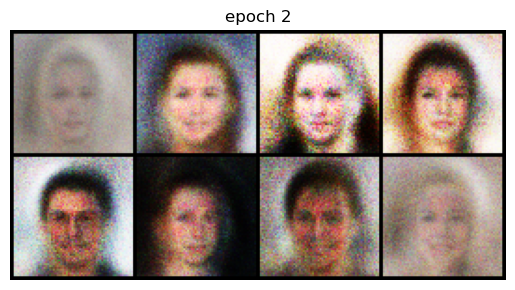

for epoch: 3/5... batch: 1... G-loss:1.6577541828155518.... D-loss: 0.5077065229415894
for epoch: 3/5... batch: 51... G-loss:1.9990367889404297.... D-loss: 0.39551958441734314
for epoch: 3/5... batch: 101... G-loss:1.504288911819458.... D-loss: 0.592709481716156
for epoch: 3/5... batch: 151... G-loss:1.866033673286438.... D-loss: 0.44140589237213135
for epoch: 3/5... batch: 201... G-loss:1.635092854499817.... D-loss: 0.5809305906295776
for epoch: 3/5... batch: 251... G-loss:1.5634510517120361.... D-loss: 0.5191962718963623
for epoch: 3/5... batch: 301... G-loss:2.1973390579223633.... D-loss: 0.4810156524181366
for epoch: 3/5... batch: 351... G-loss:2.5110936164855957.... D-loss: 0.5778912305831909
for epoch: 3/5... batch: 401... G-loss:1.808459997177124.... D-loss: 0.4934077262878418
for epoch: 3/5... batch: 451... G-loss:1.719606637954712.... D-loss: 0.45575809478759766
for epoch: 3/5... batch: 501... G-loss:1.7246140241622925.... D-loss: 0.4646170735359192
for epoch: 3/5... batch: 55

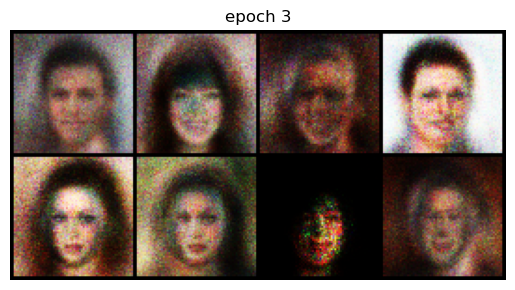

for epoch: 4/5... batch: 1... G-loss:1.2645459175109863.... D-loss: 0.57386714220047
for epoch: 4/5... batch: 51... G-loss:1.760229468345642.... D-loss: 0.480736643075943
for epoch: 4/5... batch: 101... G-loss:1.5768831968307495.... D-loss: 0.5596146583557129
for epoch: 4/5... batch: 151... G-loss:1.5744142532348633.... D-loss: 0.5647860765457153
for epoch: 4/5... batch: 201... G-loss:2.049656391143799.... D-loss: 0.5023221373558044
for epoch: 4/5... batch: 251... G-loss:1.7594491243362427.... D-loss: 0.555428147315979
for epoch: 4/5... batch: 301... G-loss:1.6680982112884521.... D-loss: 0.5410287380218506
for epoch: 4/5... batch: 351... G-loss:1.5169036388397217.... D-loss: 0.5803616046905518
for epoch: 4/5... batch: 401... G-loss:1.653578519821167.... D-loss: 0.46837514638900757
for epoch: 4/5... batch: 451... G-loss:1.687021255493164.... D-loss: 0.5012955665588379
for epoch: 4/5... batch: 501... G-loss:1.5630114078521729.... D-loss: 0.5092208385467529
for epoch: 4/5... batch: 551...

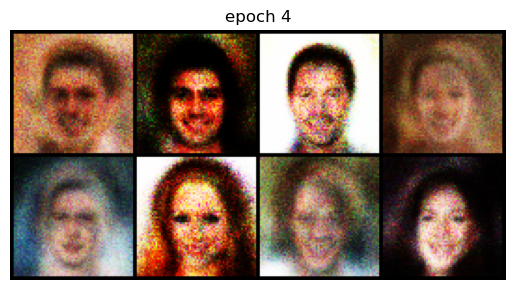

for epoch: 5/5... batch: 1... G-loss:1.4892628192901611.... D-loss: 0.5407747030258179
for epoch: 5/5... batch: 51... G-loss:1.6097348928451538.... D-loss: 0.518332302570343
for epoch: 5/5... batch: 101... G-loss:1.4621796607971191.... D-loss: 0.5273553133010864
for epoch: 5/5... batch: 151... G-loss:1.4143694639205933.... D-loss: 0.5952931642532349
for epoch: 5/5... batch: 201... G-loss:1.5927742719650269.... D-loss: 0.5183781385421753
for epoch: 5/5... batch: 251... G-loss:1.6489955186843872.... D-loss: 0.5674746036529541
for epoch: 5/5... batch: 301... G-loss:1.3110133409500122.... D-loss: 0.5422027111053467
for epoch: 5/5... batch: 351... G-loss:1.665252447128296.... D-loss: 0.45523518323898315
for epoch: 5/5... batch: 401... G-loss:1.4464459419250488.... D-loss: 0.5347222089767456
for epoch: 5/5... batch: 451... G-loss:1.5878548622131348.... D-loss: 0.6383662223815918
for epoch: 5/5... batch: 501... G-loss:1.5521740913391113.... D-loss: 0.5073971152305603
for epoch: 5/5... batch: 

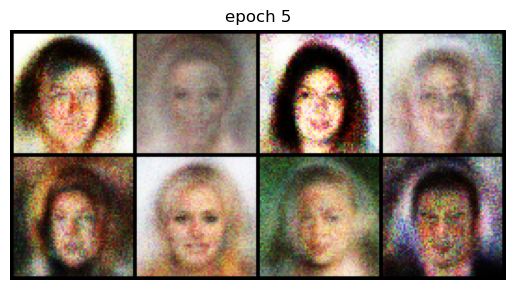

In [40]:
train(generator, discriminator, dataloader, epochs=5)